# VAE Candidate Pool Notebook

Notebook-first workflow for turning a trained attack-profile VAE into a filtered JSONL candidate pool for adversarial/POMDP experiments.

Default flow:
1. Load the curated V4 VAE checkpoint.
2. Sample decoded profiles with the empirical latent-bank sampler.
3. Filter with minimum clearance and moving-convoy dynamic outcome audit.
4. Save a JSONL candidate pool plus summary JSON.
5. Inspect spawn geometry and outcome diagnostics.


## Imports

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve repo root when this notebook is launched from either repo root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "convoy_sim").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from convoy_sim.profile_generation_viz import (
    FIXED_X_LIMITS,
    apply_limits,
    combined_limits,
    simple_ship_polygons,
    style_ax,
)
from convoy_sim.profile_outcome_audit import OutcomeAuditConfig
from convoy_sim.workflows import write_json
from experiments.audit_attack_profile_dataset import flatten_dataset_records, load_dataset_records
from experiments.generate_vae_candidate_pool import (
    build_vae_candidate_records,
    render_vae_candidate_jsonl,
)
from scenarios.convoy_profiles import get_convoy_layout_profile

PROJECT_ROOT


PosixPath('/Users/matthewplambeck/Desktop/Convoy Layout Project')

## Config

In [2]:
# Input VAE run and source data.
RUN_DIR = Path("results/runs/vae/20260511_005053_v4_notebook")
TRAIN_PATH = Path("data/attack_profiles/synthetic/train_random_tactical_v4_45k.jsonl")
CHECKPOINT_NAME = "model_best.pt"
CONVOY_PROFILE = "convoy_layout_1"

# Candidate-pool output.
OUTPUT_PATH = Path("data/attack_profiles/vae_candidates/curated_v4_hit_candidates.jsonl")
SUMMARY_PATH = OUTPUT_PATH.with_suffix(OUTPUT_PATH.suffix + ".summary.json")
RUN_GENERATION = True

# VAE sampling and filtering.
SAMPLE_COUNT = 5_000
KEEP_COUNT = 1_000
SEED = 1945
START_INDEX = 1
DEVICE = "cpu"  # cpu is slower but most reliable for this generation/audit workflow
SAMPLING_METHOD = "latent_bank"  # latent_bank or prior
LATENT_NOISE_SCALE = 0.10
MIN_CLEARANCE_M = 250.0
ACCEPTED_OUTCOMES = ("credible_hit_threat",)

# Dynamic audit settings.
DYNAMIC_AUDIT_T_MAX_S = 600.0
DYNAMIC_AUDIT_DT_S = 0.5

# Plotting.
TRAIN_COMPARE_LIMIT = 5_000


## Generate Or Load Candidate Pool

In [3]:
if RUN_GENERATION:
    candidate_records, summary = build_vae_candidate_records(
        run_dir=PROJECT_ROOT / RUN_DIR,
        train_path=PROJECT_ROOT / TRAIN_PATH,
        checkpoint_name=CHECKPOINT_NAME,
        sample_count=int(SAMPLE_COUNT),
        keep_count=int(KEEP_COUNT) if KEEP_COUNT is not None else None,
        seed=int(SEED),
        start_index=int(START_INDEX),
        convoy_profile=CONVOY_PROFILE,
        device=DEVICE,
        sampling_method=SAMPLING_METHOD,
        latent_noise_scale=float(LATENT_NOISE_SCALE),
        min_clearance_m=float(MIN_CLEARANCE_M),
        accepted_outcomes=ACCEPTED_OUTCOMES,
        outcome_cfg=OutcomeAuditConfig(t_max_s=float(DYNAMIC_AUDIT_T_MAX_S), hit_dt_s=float(DYNAMIC_AUDIT_DT_S)),
    )
    output_path = PROJECT_ROOT / OUTPUT_PATH
    summary_path = PROJECT_ROOT / SUMMARY_PATH
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(render_vae_candidate_jsonl(candidate_records), encoding="utf-8")
    write_json(summary_path, summary)
else:
    output_path = PROJECT_ROOT / OUTPUT_PATH
    summary_path = PROJECT_ROOT / SUMMARY_PATH
    candidate_records = load_dataset_records(output_path)
    summary = json.loads(summary_path.read_text(encoding="utf-8"))

print(f"candidate_records: {len(candidate_records):,}")
print(f"output_path: {output_path}")
print(f"summary_path: {summary_path}")


candidate_records: 1,000
output_path: /Users/matthewplambeck/Desktop/Convoy Layout Project/data/attack_profiles/vae_candidates/curated_v4_hit_candidates.jsonl
summary_path: /Users/matthewplambeck/Desktop/Convoy Layout Project/data/attack_profiles/vae_candidates/curated_v4_hit_candidates.jsonl.summary.json


## Summary

In [4]:
summary_view = {
    "sample_count": summary.get("sample_count"),
    "accepted_count": summary.get("accepted_count"),
    "filtered_out_count": summary.get("filtered_out_count"),
    "sampling_method": summary.get("sampling_method"),
    "latent_noise_scale": summary.get("latent_noise_scale"),
    "accepted_outcomes": summary.get("accepted_outcomes"),
    "accepted_labels": summary.get("accepted_labels"),
    "accepted_spawn_regions": summary.get("accepted_spawn_regions"),
    "pre_filter_audit": summary.get("pre_filter_audit"),
}
summary_view


{'sample_count': 5000,
 'accepted_count': 1000,
 'filtered_out_count': 4000,
 'sampling_method': 'latent_bank',
 'latent_noise_scale': 0.1,
 'accepted_outcomes': ['credible_hit_threat'],
 'accepted_labels': {'credible_hit_threat': 1000},
 'accepted_spawn_regions': {'port_vae': 161,
  'inside_convoy_envelope': 180,
  'astern_vae': 202,
  'ahead_vae': 285,
  'starboard_vae': 172},
 'pre_filter_audit': {'samples': 5000,
  'actual_outcome_labels': {'credible_hit_threat': 4583,
   'credible_near_miss': 347,
   'miss': 70},
  'centroid_static_labels': {'implausible_geometry': 4611,
   'credible_hit_threat': 389},
  'clearance_ok_rate': 0.9008,
  'passes_safety_gate_rate': 0.9008,
  'min_clearance_m': 4.498896234583991,
  'any_ship_hit_rate': 0.9166,
  'mean_hits': 2.8112,
  'mean_unique_ships_hit': 1.683,
  'mean_closest_any_ship_distance_m': 29.8366377588177}}

## Flatten Candidate Records

In [5]:
def candidate_records_to_df(records: list[dict]) -> pd.DataFrame:
    rows = []
    for record in records:
        profile = dict(record["profile"])
        audit = dict(record["audit"])
        intent = dict(record.get("intent", {}))
        outcome = dict(record.get("outcome", {}))
        rows.append({
            "profile_id": str(profile["profile_id"]),
            "u_pos": list(profile["u_pos"]),
            "u_pos_x": float(profile["u_pos"][0]),
            "u_pos_y": float(profile["u_pos"][1]),
            "spawn_region": str(intent.get("spawn_region", audit.get("spawn_region", ""))),
            "approach_side": str(intent.get("approach_side", audit.get("approach_side", ""))),
            "inside_convoy_envelope": bool(intent.get("inside_convoy_envelope", audit.get("inside_convoy_envelope", False))),
            "suggested_label": str(audit.get("suggested_label", "")),
            "actual_outcome_label": str(audit.get("actual_outcome_label", outcome.get("actual_outcome_label", ""))),
            "clearance_m": float(audit.get("clearance_m", np.nan)),
            "n_hits": int(audit.get("n_hits", outcome.get("n_hits", 0))),
            "unique_ships_hit": int(audit.get("unique_ships_hit", outcome.get("unique_ships_hit", 0))),
            "closest_any_ship_distance_m": float(audit.get("closest_any_ship_distance_m", np.nan)),
            "closest_any_ship_id": str(audit.get("closest_any_ship_id", outcome.get("closest_any_ship_id", ""))),
            "passes_gate": True,
        })
    return pd.DataFrame(rows)

candidate_df = candidate_records_to_df(candidate_records)
candidate_df.head()


,profile_id,u_pos,u_pos_x,u_pos_y,spawn_region,approach_side,inside_convoy_envelope,suggested_label,actual_outcome_label,clearance_m,n_hits,unique_ships_hit,closest_any_ship_distance_m,closest_any_ship_id,passes_gate
0,VAE000001,"[127.014404296875, 5683.83154296875]",127.014404,5683.831543,port_vae,port,False,credible_hit_threat,credible_hit_threat,1572.316640,3,1,3.254029,S34,True
1,VAE000003,"[-197.35430908203125, -3557.861328125]",-197.354309,-3557.861328,inside_convoy_envelope,inside,True,credible_hit_threat,credible_hit_threat,557.814465,3,2,9.500546,S41,True
2,VAE000004,"[-592.7037353515625, 1095.6478271484375]",-592.703735,1095.647827,inside_convoy_envelope,inside,True,credible_hit_threat,credible_hit_threat,291.232753,2,2,15.669370,S29,True
3,VAE000005,"[-3657.54248046875, -178.96942138671875]",-3657.542480,-178.969421,astern_vae,astern,False,credible_hit_threat,credible_hit_threat,2520.903398,3,2,7.031558,S18,True
4,VAE000007,"[2135.45263671875, 1741.9942626953125]",2135.452637,1741.994263,ahead_vae,ahead,False,credible_hit_threat,credible_hit_threat,1059.317774,2,1,20.414671,S28,True


## Candidate Distributions

In [6]:
distribution_tables = {
    "actual_outcome_label": candidate_df["actual_outcome_label"].value_counts().to_dict(),
    "spawn_region": candidate_df["spawn_region"].value_counts().to_dict(),
    "approach_side": candidate_df["approach_side"].value_counts().to_dict(),
    "inside_convoy_envelope": candidate_df["inside_convoy_envelope"].value_counts().to_dict(),
}
distribution_tables


{'actual_outcome_label': {'credible_hit_threat': 1000},
 'spawn_region': {'ahead_vae': 285,
  'astern_vae': 202,
  'inside_convoy_envelope': 180,
  'starboard_vae': 172,
  'port_vae': 161},
 'approach_side': {'ahead': 285,
  'astern': 202,
  'inside': 180,
  'starboard': 172,
  'port': 161},
 'inside_convoy_envelope': {False: 820, True: 180}}

## Training Vs Candidate Spawns

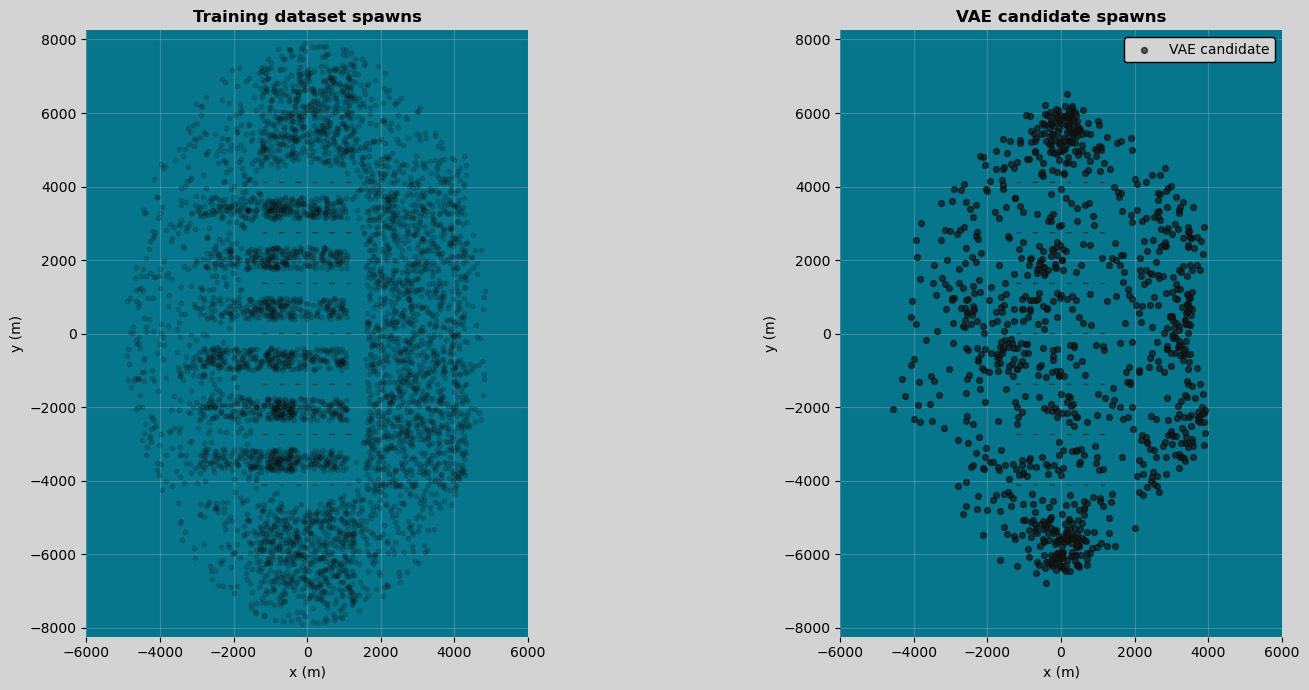

In [7]:
ships = get_convoy_layout_profile(CONVOY_PROFILE).build_ships()
train_records = load_dataset_records(PROJECT_ROOT / TRAIN_PATH)
train_rows = flatten_dataset_records(train_records[: int(TRAIN_COMPARE_LIMIT)])
train_df = pd.DataFrame(train_rows)
train_df["u_pos"] = train_df[["u_pos_x", "u_pos_y"]].values.tolist()

train_points = np.vstack(train_df["u_pos"].to_list()) if len(train_df) else None
candidate_points = np.vstack(candidate_df["u_pos"].to_list()) if len(candidate_df) else None
extra_sets = [p for p in [train_points, candidate_points] if p is not None]
shared_limits = combined_limits(ships, extra_points=np.vstack(extra_sets) if extra_sets else None, pad=350.0)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor="lightgrey")
style_ax(axes[0], "Training dataset spawns")
simple_ship_polygons(axes[0], ships)
if len(train_df):
    train_xy = np.vstack(train_df["u_pos"].to_list())
    axes[0].scatter(train_xy[:, 0], train_xy[:, 1], c="#111111", s=10, alpha=0.18, zorder=2)
apply_limits(axes[0], shared_limits, fixed_x_limits=FIXED_X_LIMITS)
axes[0].set_xlabel("x (m)")
axes[0].set_ylabel("y (m)")

style_ax(axes[1], "VAE candidate spawns")
simple_ship_polygons(axes[1], ships)
if len(candidate_df):
    candidate_xy = np.vstack(candidate_df["u_pos"].to_list())
    axes[1].scatter(candidate_xy[:, 0], candidate_xy[:, 1], c="#111111", s=18, alpha=0.65, zorder=2, label="VAE candidate")
    axes[1].legend(frameon=True, facecolor="lightgrey", edgecolor="black", framealpha=1.0)
apply_limits(axes[1], shared_limits, fixed_x_limits=FIXED_X_LIMITS)
axes[1].set_xlabel("x (m)")
axes[1].set_ylabel("y (m)")
plt.tight_layout()
plt.show()


## Candidate Spawns By Region

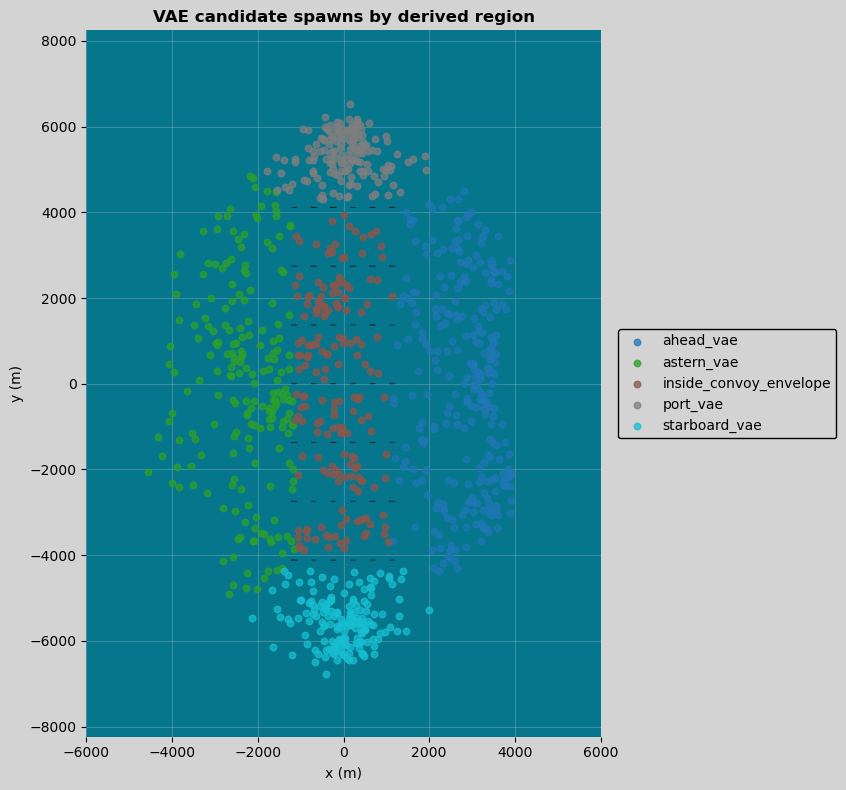

In [8]:
region_values = sorted(candidate_df["spawn_region"].dropna().unique().tolist())
colors = plt.cm.tab10(np.linspace(0, 1, max(len(region_values), 1)))
color_map = dict(zip(region_values, colors))

fig, ax = plt.subplots(figsize=(10, 8), facecolor="lightgrey")
style_ax(ax, "VAE candidate spawns by derived region")
simple_ship_polygons(ax, ships)
for region in region_values:
    region_df = candidate_df.loc[candidate_df["spawn_region"] == region]
    if not len(region_df):
        continue
    xy = np.vstack(region_df["u_pos"].to_list())
    ax.scatter(xy[:, 0], xy[:, 1], s=22, alpha=0.75, color=color_map[region], label=region, zorder=2)
apply_limits(ax, shared_limits, fixed_x_limits=FIXED_X_LIMITS)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True, facecolor="lightgrey", edgecolor="black", framealpha=1.0)
plt.tight_layout()
plt.show()


## Outcome Diagnostics

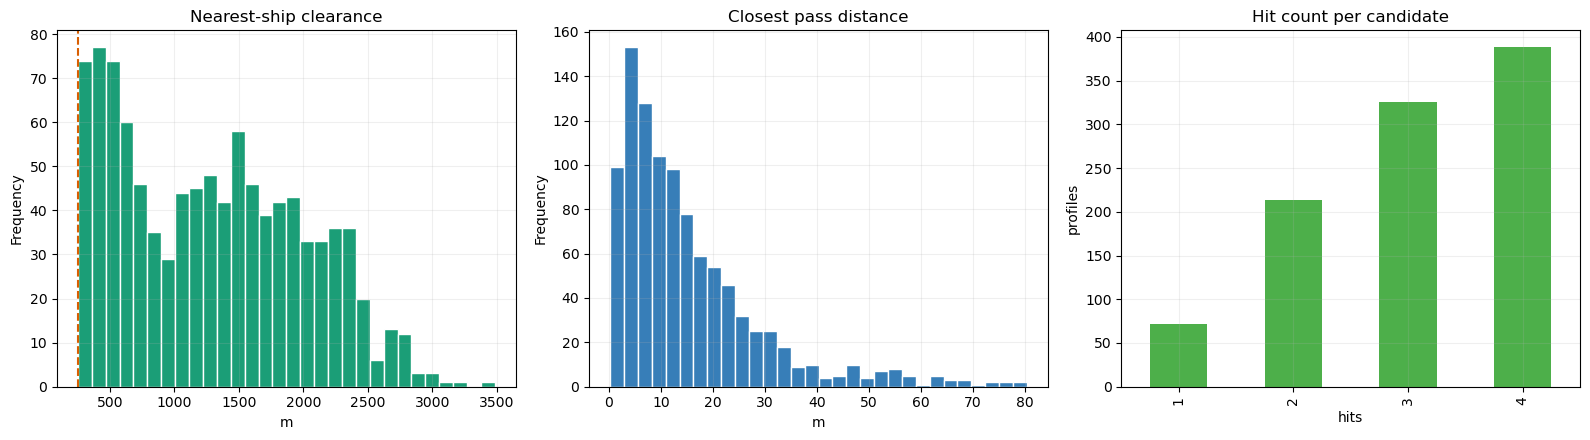

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), facecolor="white")

candidate_df["clearance_m"].plot.hist(ax=axes[0], bins=30, color="#1b9e77", edgecolor="white")
axes[0].axvline(MIN_CLEARANCE_M, color="#d95f02", linestyle="--", linewidth=1.5)
axes[0].set_title("Nearest-ship clearance")
axes[0].set_xlabel("m")

candidate_df["closest_any_ship_distance_m"].plot.hist(ax=axes[1], bins=30, color="#377eb8", edgecolor="white")
axes[1].set_title("Closest pass distance")
axes[1].set_xlabel("m")

candidate_df["n_hits"].value_counts().sort_index().plot.bar(ax=axes[2], color="#4daf4a")
axes[2].set_title("Hit count per candidate")
axes[2].set_xlabel("hits")
axes[2].set_ylabel("profiles")

for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## Artifact Paths

In [10]:
{
    "candidate_jsonl": str(PROJECT_ROOT / OUTPUT_PATH),
    "summary_json": str(PROJECT_ROOT / SUMMARY_PATH),
    "record_count": int(len(candidate_records)),
}


{'candidate_jsonl': '/Users/matthewplambeck/Desktop/Convoy Layout Project/data/attack_profiles/vae_candidates/curated_v4_hit_candidates.jsonl',
 'summary_json': '/Users/matthewplambeck/Desktop/Convoy Layout Project/data/attack_profiles/vae_candidates/curated_v4_hit_candidates.jsonl.summary.json',
 'record_count': 1000}